# 02 Baseline ASR Evaluation


Evaluasi enam model ASR pre-trained (tanpa fine-tuning) pada rekaman presentasi mahasiswa Filkom UB.

**Models:**
- A · `faster-whisper medium`
- B · `faster-whisper large-v3-turbo`
- C · `Wav2Vec 2.0 XLSR-53 Indonesian`
- D · `Qwen2-Audio-7B-Instruct`
- E · `whisper medium`
- F · `whisper large-v3-turbo`

**Metrik:** WER · CER · RTF · TTER (Tech Term Error Rate)

## 1. Install Dependencies

In [1]:
!pip install -q \
    faster-whisper \
    transformers \
    accelerate \
    jiwer \
    librosa \
    soundfile \
    imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 54.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 41.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.9 MB/s eta 0:00:00:00:01


## 2. Import & Konfigurasi

In [2]:
import os, time, json, warnings, re, subprocess
import numpy as np
import librosa
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from jiwer import wer, cer
import imageio_ffmpeg

warnings.filterwarnings('ignore')

DATA_DIR   = Path('/kaggle/input/datasets/aufiifathin/raw-presentasi/raw/presentasi')
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE = 16_000
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device     : {DEVICE}')
print(f'Data dir   : {DATA_DIR.resolve()}')
if DEVICE == 'cuda':
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
    print(f'VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device     : cuda
Data dir   : /kaggle/input/datasets/aufiifathin/raw-presentasi/raw/presentasi
GPU        : Tesla T4
VRAM       : 15.6 GB


## 3. Load Data

In [6]:
AUDIO_EXTS = ['.wav', '.WAV', '.mp4', '.m4a', '.ogg', '.mp3', '.flac']
all_audio = [f for f in DATA_DIR.iterdir()
             if f.suffix in AUDIO_EXTS and 'audio' in f.name.lower()]
all_audio = sorted(all_audio)

sessions = []
for af in all_audio:
    gt_name = af.name.replace('audio', 'teks')
    gt_name = re.sub(r'\.(wav|WAV|mp4|m4a|ogg|mp3|flac)$', '.txt', gt_name)
    gt_path = DATA_DIR / gt_name
    
    if gt_path.exists():
        sessions.append({'audio': af, 'gt': gt_path})
        print(f'✅  {af.name:35s} → {gt_path.name}')
    else:
        print(f'⚠️  {af.name:35s} → ground truth tidak ditemukan, skip')

assert sessions, 'Tidak ada pasangan audio+ground truth yang ditemukan!'
print(f'\n→ {len(sessions)} sesi siap dievaluasi')

✅  presentasi1-audio.WAV               → presentasi1-teks.txt
✅  presentasi2-audio.WAV               → presentasi2-teks.txt
✅  presentasi3-audio.wav               → presentasi3-teks.txt

→ 3 sesi siap dievaluasi


## 4. Preprocessing, Konversi ke WAV 16kHz

In [7]:
def normalize_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def convert_to_wav16k(audio_path: Path, output_dir: Path) -> Path:
    out = output_dir / (audio_path.stem + '_16k.wav')
    if out.exists():
        return out
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    cmd = [ffmpeg, '-i', str(audio_path),
           '-ac', '1', '-ar', str(SAMPLE_RATE),
           str(out), '-y', '-loglevel', 'error']
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'ffmpeg error: {r.stderr}')
    return out

print('Memproses file audio...')
for s in sessions:
    s['wav']          = convert_to_wav16k(s['audio'], OUTPUT_DIR)
    s['audio_array'], _ = librosa.load(str(s['wav']), sr=SAMPLE_RATE, mono=True)
    s['duration']     = len(s['audio_array']) / SAMPLE_RATE
    s['gt_raw']       = s['gt'].read_text(encoding='utf-8')
    s['gt_norm']      = normalize_text(s['gt_raw'])
    print(f'  {s["audio"].name}: {s["duration"]:.1f}s '
          f'({s["duration"]/60:.1f} mnt) | GT: {len(s["gt_norm"].split())} kata')


Memproses file audio...
  presentasi1-audio.WAV: 90.7s (1.5 mnt) | GT: 193 kata
  presentasi2-audio.WAV: 122.7s (2.0 mnt) | GT: 270 kata
  presentasi3-audio.wav: 233.2s (3.9 mnt) | GT: 474 kata


## 5. Helper Evaluasi & Tech Term Analysis

In [8]:
TECH_TERMS = [
    # CS Fundamentals
    'algoritma', 'fungsi', 'variabel', 'array', 'rekursi', 'iterasi',
    'stack', 'queue', 'tree', 'graph', 'node', 'edge', 'branch',
    # OOP (presentasi2: Class Diagram, Abstract, Constructor)
    'class', 'abstract', 'constructor', 'method', 'attribute', 'interface',
    'inheritance', 'override', 'polymorphism', 'encapsulation', 'instansiasi',
    'object', 'diagram',
    # Graph & Algorithm (presentasi3: Graph Coloring, Backtracking, DFS)
    'backtracking', 'coloring', 'pewarnaan', 'simpul', 'dead node',
    'depth first search', 'dfs', 'eliminasi',
    # CV/ML (presentasi1: CNN, preprocessing, feature extraction)
    'preprocessing', 'classification', 'segmentasi', 'ekstraksi',
    'dataset', 'convolutional', 'cnn', 'feature extraction',
    'smoothing', 'resize', 'tekstur',
    # General CS
    'pipeline', 'implementasi', 'sistem', 'parameter', 'output', 'input',
]

results_all = {}

def evaluate(model_name, hypothesis, gt_raw, inference_time, duration):
    hyp = normalize_text(hypothesis)
    ref = normalize_text(gt_raw)

    word_err = wer(ref, hyp)
    char_err = cer(ref, hyp)
    rtf      = inference_time / duration

    # TTER: berapa % kata teknis yang miss
    tech_in_ref  = [t for t in TECH_TERMS if t in ref]
    tech_correct = [t for t in tech_in_ref if t in hyp]
    tech_missed  = [t for t in tech_in_ref if t not in hyp]
    tter = (len(tech_missed) / len(tech_in_ref) * 100) if tech_in_ref else 0.0

    return {
        'model'         : model_name,
        'wer'           : round(word_err * 100, 2),
        'cer'           : round(char_err * 100, 2),
        'rtf'           : round(rtf, 4),
        'tter'          : round(tter, 2),
        'inference_sec' : round(inference_time, 2),
        'duration_sec'  : round(duration, 2),
        'tech_in_ref'   : tech_in_ref,
        'tech_correct'  : tech_correct,
        'tech_missed'   : tech_missed,
        'transcription' : hypothesis,
    }

def print_result(res, session_name=''):
    label = f'{res["model"]}' + (f' | {session_name}' if session_name else '')
    print(f'\n{"="*58}')
    print(f'  {label}')
    print(f'  WER  : {res["wer"]:6.2f}%  {"✅" if res["wer"] < 20 else "⚠️"}')
    print(f'  CER  : {res["cer"]:6.2f}%')
    print(f'  RTF  : {res["rtf"]:6.4f}   {"✅ real-time" if res["rtf"] < 1 else "⚠️ lambat"}')
    print(f'  TTER : {res["tter"]:6.2f}%  (tech term miss rate)')
    print(f'  Teknis benar  : {res["tech_correct"]}')
    print(f'  Teknis terlewat: {res["tech_missed"]}')
    print(f'{"─"*58}')
    print(' '.join(res['transcription'].split()[:120]))

## 5b. Helper Unload Model (Anti-OOM)

In [9]:
import gc

def unload_model(*models):
    """Hapus model dari VRAM setelah selesai dipakai."""
    for m in models:
        del m
    gc.collect()
    torch.cuda.empty_cache()
    if DEVICE == 'cuda':
        used = torch.cuda.memory_allocated() / 1e9
        print(f'VRAM setelah unload: {used:.2f} GB')


## 6. Model A: faster-whisper medium

In [10]:
from faster_whisper import WhisperModel

whisper_model = WhisperModel('medium', device=DEVICE, compute_type='int8_float16')
print('faster-whisper medium loaded.')


faster-whisper medium loaded.


In [11]:
results_all = {}
results_all['faster_whisper_medium'] = []

for s in sessions:
    t0 = time.time()
    segments, _ = whisper_model.transcribe(
        str(s['wav']),
        language='id',
        beam_size=5,
        condition_on_previous_text=True,
        vad_filter=True,
        vad_parameters=dict(min_silence_duration_ms=300),
    )
    text    = ' '.join(seg.text.strip() for seg in segments)
    elapsed = time.time() - t0

    res = evaluate('faster-whisper medium', text, s['gt_raw'], elapsed, s['duration'])
    results_all['faster_whisper_medium'].append(res)
    print_result(res, s['audio'].name)
    (OUTPUT_DIR / f'whisper_medium_{s["audio"].stem}.txt').write_text(text, encoding='utf-8')

print('\n✅ Whisper medium selesai.')
unload_model(whisper_model)



  faster-whisper medium | presentasi1-audio.WAV
  WER  :  70.98%  ⚠️
  CER  :  39.23%
  RTF  : 0.0894   ✅ real-time
  TTER :  66.67%  (tech term miss rate)
  Teknis benar  : ['class', 'preprocessing', 'pipeline', 'sistem']
  Teknis terlewat: ['classification', 'segmentasi', 'dataset', 'cnn', 'feature extraction', 'smoothing', 'resize', 'tekstur']
──────────────────────────────────────────────────────────
Pada tahun 2001, semua perempangan dari kelas pengolahan cita juga redi gratis komputer Dengan ini 2351-5026-0111 Dan juga di sini saya akomunikasi bersama teman saya Yaitu Dujia Hemabadi yang ini 2351-5026-0111-0121 Ini 3800 jahat dan terkait dengan progress project akhir PCE di UK Yang kemarin dulu pagi menghabis dulu smartwish classifier Yang namanya menghubungi klasik di klasik kan? Organic yaitu juga unorganic Untuk deskripsi project ini semuanya lebih lanjut Di sini kami akan mengambil sistem klasik di klasik sampah Untuk menjadi dua kategori yaitu organic dan unorganic Ini adal

## 7. Model B: faster-whisper large-v3-turbo

In [12]:
whisper_turbo = WhisperModel('large-v3-turbo', device=DEVICE, compute_type='int8')
print('faster-whisper large-v3-turbo loaded.')


faster-whisper large-v3-turbo loaded.


In [13]:
results_all['faster_whisper_turbo'] = []

for s in sessions:
    t0 = time.time()
    segments, _ = whisper_turbo.transcribe(
        str(s['wav']),
        language='id',
        beam_size=5,
        condition_on_previous_text=True,
        vad_filter=True,
        vad_parameters=dict(min_silence_duration_ms=300),
    )
    text = ' '.join(seg.text.strip() for seg in segments)
    elapsed = time.time() - t0

    res = evaluate('faster-whisper large-v3-turbo', text, s['gt_raw'], elapsed, s['duration'])
    results_all['faster_whisper_turbo'].append(res)
    print_result(res, s['audio'].name)
    (OUTPUT_DIR / f'whisper_turbo_{s["audio"].stem}.txt').write_text(text, encoding='utf-8')

print('\n✅ Whisper turbo selesai.')
unload_model(whisper_turbo)



  faster-whisper large-v3-turbo | presentasi1-audio.WAV
  WER  : 100.00%  ⚠️
  CER  :  97.33%
  RTF  : 0.0177   ✅ real-time
  TTER : 100.00%  (tech term miss rate)
  Teknis benar  : []
  Teknis terlewat: ['class', 'preprocessing', 'classification', 'segmentasi', 'dataset', 'cnn', 'feature extraction', 'smoothing', 'resize', 'tekstur', 'pipeline', 'sistem']
──────────────────────────────────────────────────────────
Terima kasih. Terima kasih. Terima kasih.

  faster-whisper large-v3-turbo | presentasi2-audio.WAV
  WER  :  35.19%  ⚠️
  CER  :  16.28%
  RTF  : 0.0364   ✅ real-time
  TTER :  66.67%  (tech term miss rate)
  Teknis benar  : ['interface', 'override', 'diagram']
  Teknis terlewat: ['class', 'abstract', 'constructor', 'method', 'attribute', 'implementasi']
──────────────────────────────────────────────────────────
Di sini saya akan menjelaskan bersama dengan pekan saya, yaitu Nui Cahaya Malang dengan 2351-502-0111-103. Dan mungkin ini akan langsung saya bawa yang pertama. Nah,

## 8. Model C: Wav2Vec 2.0 XLSR-53 Indonesian

In [3]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

W2V_ID = 'indonesian-nlp/wav2vec2-large-xlsr-indonesian'
w2v_processor = Wav2Vec2Processor.from_pretrained(W2V_ID)
w2v_model     = Wav2Vec2ForCTC.from_pretrained(W2V_ID).to(DEVICE)
w2v_model.eval()
print('Wav2Vec 2.0 loaded.')


preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/250 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

Wav2Vec 2.0 loaded.


In [20]:
def wav2vec_infer(audio, chunk_sec=25, overlap_sec=1):
    chunk_s, overlap_s = chunk_sec * SAMPLE_RATE, overlap_sec * SAMPLE_RATE
    step, segs = chunk_s - overlap_s, []
    for start in range(0, len(audio), step):
        chunk = audio[start : start + chunk_s]
        if len(chunk) < 1600:
            continue
        inp = w2v_processor(chunk, sampling_rate=SAMPLE_RATE,
                            return_tensors='pt', padding=True).input_values.to(DEVICE)
        with torch.no_grad():
            logits = w2v_model(inp).logits
        segs.append(w2v_processor.batch_decode(torch.argmax(logits, -1))[0].strip())
    return ' '.join(segs)

results_all['wav2vec2_xlsr'] = []

for s in sessions:
    t0   = time.time()
    text = wav2vec_infer(s['audio_array'])
    elapsed = time.time() - t0

    res = evaluate('Wav2Vec 2.0 XLSR-53', text, s['gt_raw'], elapsed, s['duration'])
    results_all['wav2vec2_xlsr'].append(res)
    print_result(res, s['audio'].name)
    (OUTPUT_DIR / f'wav2vec_{s["audio"].stem}.txt').write_text(text, encoding='utf-8')

print('\n✅ Wav2Vec selesai.')
unload_model(w2v_model)
del w2v_processor



  Wav2Vec 2.0 XLSR-53 | presentasi1-audio.WAV
  WER  :  96.89%  ⚠️
  CER  :  68.14%
  RTF  : 0.0144   ✅ real-time
  TTER : 100.00%  (tech term miss rate)
  Teknis benar  : []
  Teknis terlewat: ['class', 'preprocessing', 'classification', 'segmentasi', 'dataset', 'cnn', 'feature extraction', 'smoothing', 'resize', 'tekstur', 'pipeline', 'sistem']
──────────────────────────────────────────────────────────
kamkahu buan tuusuapergimakan saahdisan sudaadadari kelas tahanolag kaang kida iara kpaa siagita dengan ida didir lasi watetupahotinutsua ta salu suat idi tiga pendaaya kain mtida ke pemapanayaayahkudisioaapakantikua di dua kiapasakumkipatntuan tahn an sata tutusaltlahal tuuka anakantaan kemalam ilasanakai dita imabrorsbantitakhad peca herpinsatayan kemmarieaman diibui sai sekosi payadiriyang lagiiy amadikasi dikasiaraapor gada idiada penaainkaasitu dispiimacaisarusa bilai kuuanaatsinamiyang kakagkalajiapasiaiasisaemahdaaadiindua ka tahodi i kekardari danlaisindilamu kugan iaa ekai in

## 9. VRAM Reset

In [41]:
import gc, torch

for var in ['w2v_model', 'w2v_processor', 'whisper_model', 'whisper_turbo']:
    if var in dir():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

free, total = torch.cuda.mem_get_info()
print(f"VRAM bebas : {free/1e9:.2f} GB")
print(f"VRAM total : {total/1e9:.2f} GB")

VRAM bebas : 8.95 GB
VRAM total : 15.64 GB


## 10. Model D: Qwen2-Audio-7B

In [38]:
from transformers import Qwen2AudioForConditionalGeneration, AutoProcessor

QWEN_ID = 'Qwen/Qwen2-Audio-7B-Instruct'
qwen_processor = AutoProcessor.from_pretrained(QWEN_ID, trust_remote_code=True)
qwen_model = Qwen2AudioForConditionalGeneration.from_pretrained(
    QWEN_ID,
    torch_dtype=torch.float16,
    device_map='auto',
    trust_remote_code=True,
)
qwen_model.eval()
print('Qwen2-Audio-7B loaded.')

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/876 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Qwen2-Audio-7B loaded.


In [52]:
import inspect
print(inspect.signature(qwen_processor.__call__))

(text: str | list[str] | list[list[str]] = None, audio: numpy.ndarray | list[numpy.ndarray] = None, **kwargs: Unpack[transformers.models.qwen2_audio.processing_qwen2_audio.Qwen2AudioProcessorKwargs]) -> transformers.feature_extraction_utils.BatchFeature


In [53]:
def qwen_transcribe(audio_array, sr=16000) -> str:
    conversation = [
        {'role': 'system', 'content': 'You are a helpful speech transcription assistant.'},
        {"role": "user", "content": [
            {"type": "audio", "audio_url": "placeholder"},
            {"type": "text", "text": "Please transcribe this audio accurately in Bahasa Indonesia. Output only the transcription text, nothing else."},
        ]},
    ]

    text = qwen_processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)

    inputs = qwen_processor(
        text=text,
        audio=[audio_array],
        return_tensors="pt",
        padding=True,
        sampling_rate=sr,
    )
    inputs.input_ids = inputs.input_ids.to("cuda")

    generate_ids = qwen_model.generate(**inputs, max_new_tokens=256)
    generate_ids = generate_ids[:, inputs.input_ids.size(1):]

    return qwen_processor.batch_decode(
        generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()

results_all['qwen2_audio_7b'] = []

for s in sessions:
    print(f"⏳ Processing {s['audio'].name} ({s['duration']/60:.1f} mnt)...")
    t0   = time.time()
    text = qwen_transcribe(s['audio_array'])
    elapsed = time.time() - t0
    print(f"   selesai dalam {elapsed/60:.1f} menit")

    res = evaluate('Qwen2-Audio-7B', text, s['gt_raw'], elapsed, s['duration'])
    results_all['qwen2_audio_7b'].append(res)
    print_result(res, s['audio'].name)
    (OUTPUT_DIR / f'qwen2audio_{s["audio"].stem}.txt').write_text(text, encoding='utf-8')

print('\n✅ Qwen2-Audio selesai.')
unload_model(qwen_model)
del qwen_processor

⏳ Processing presentasi1-audio.WAV (1.5 mnt)...
   selesai dalam 2.4 menit

  Qwen2-Audio-7B | presentasi1-audio.WAV
  WER  :  91.71%  ⚠️
  CER  :  84.42%
  RTF  : 1.5809   ⚠️ lambat
  TTER :  91.67%  (tech term miss rate)
  Teknis benar  : ['sistem']
  Teknis terlewat: ['class', 'preprocessing', 'classification', 'segmentasi', 'dataset', 'cnn', 'feature extraction', 'smoothing', 'resize', 'tekstur', 'pipeline']
──────────────────────────────────────────────────────────
Dari kelas berikutnya kita dengan lima komputer dengan sistem operasi Windows XP dan juga saya akan memberikan contoh-contoh yang ada di sini itu dari media flash yang saya punya yaitu dari CD yang nomor satu itu adalah dari pihak Microsoft yang nomor seri-nya adalah F04-S00-5239-0000.
⏳ Processing presentasi2-audio.WAV (2.0 mnt)...
   selesai dalam 2.1 menit

  Qwen2-Audio-7B | presentasi2-audio.WAV
  WER  :  95.19%  ⚠️
  CER  :  86.17%
  RTF  : 1.0151   ⚠️ lambat
  TTER : 100.00%  (tech term miss rate)
  Teknis benar 

## 11. Model E: whisper medium

In [58]:
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 11.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [59]:
import whisper

whisper_orig = whisper.load_model('medium', device=DEVICE)
print('whisper medium loaded.')

100%|█████████████████████████████████████| 1.42G/1.42G [00:18<00:00, 81.2MiB/s]


whisper medium loaded.


In [60]:
results_all['whisper_medium'] = []

for s in sessions:
    t0 = time.time()
    result = whisper_orig.transcribe(
        str(s['wav']),
        language='id',
        beam_size=5,
        condition_on_previous_text=True,
    )
    text = result['text'].strip()
    elapsed = time.time() - t0

    res = evaluate('whisper medium', text, s['gt_raw'], elapsed, s['duration'])
    results_all['whisper_medium'].append(res)
    print_result(res, s['audio'].name)
    (OUTPUT_DIR / f'whisper_orig_{s["audio"].stem}.txt').write_text(text, encoding='utf-8')

print('\n✅ Whisper medium selesai.')
unload_model(whisper_orig)


  whisper medium | presentasi1-audio.WAV
  WER  :  66.84%  ⚠️
  CER  :  38.11%
  RTF  : 0.3040   ✅ real-time
  TTER :  75.00%  (tech term miss rate)
  Teknis benar  : ['class', 'preprocessing', 'sistem']
  Teknis terlewat: ['classification', 'segmentasi', 'dataset', 'cnn', 'feature extraction', 'smoothing', 'resize', 'tekstur', 'pipeline']
──────────────────────────────────────────────────────────
Pada tahun 2001, semua pertahankan saya, Afiq Nabila, dari kelas kuala hencita juga dan juga kelas komputer dengan ini 2351-5026-0111 dan juga di sini saya, aku melihatkan pesan teman-teman saya yaitu Drujah Hemamani, yang ini 2351-5026-01102 Ini 3800 standar, kait dengan progress project akhir PNC di UK yang kemarin dulu-dulu menghabis, dulu mengaduis, kelasi payah yang namanya mengklasifikasikan organik, yaitu unorganik Untuk deskripsi project ini semuanya lebih lancar di sini kami akan memberi sistem klasifikasi bersama untuk menjadi dua kategori, yaitu organik dan unorganik Ini menggunak

## 11. Model E: whisper large-v3-turbo

In [61]:
whisper_turbo_orig = whisper.load_model('large-v3-turbo', device=DEVICE)
print('whisper original large-v3-turbo loaded.')

100%|██████████████████████████████████████| 1.51G/1.51G [00:14<00:00, 114MiB/s]


whisper original large-v3-turbo loaded.


In [62]:
results_all['whisper_turbo'] = []

for s in sessions:
    t0 = time.time()
    result = whisper_turbo_orig.transcribe(
        str(s['wav']),
        language='id',
        beam_size=5,
        condition_on_previous_text=True,
    )
    text = result['text'].strip()
    elapsed = time.time() - t0

    res = evaluate('whisper large-v3-turbo', text, s['gt_raw'], elapsed, s['duration'])
    results_all['whisper_turbo'].append(res)
    print_result(res, s['audio'].name)
    (OUTPUT_DIR / f'whisper_orig_turbo_{s["audio"].stem}.txt').write_text(text, encoding='utf-8')

print('\n✅ Whisper large-v3-turbo selesai.')
unload_model(whisper_turbo_orig)


  whisper large-v3-turbo | presentasi1-audio.WAV
  WER  : 100.00%  ⚠️
  CER  :  92.70%
  RTF  : 0.0193   ✅ real-time
  TTER : 100.00%  (tech term miss rate)
  Teknis benar  : []
  Teknis terlewat: ['class', 'preprocessing', 'classification', 'segmentasi', 'dataset', 'cnn', 'feature extraction', 'smoothing', 'resize', 'tekstur', 'pipeline', 'sistem']
──────────────────────────────────────────────────────────
Terima kasih telah menonton Terima kasih telah menonton Terima kasih telah menonton Terima kasih telah menonton

  whisper large-v3-turbo | presentasi2-audio.WAV
  WER  :  32.22%  ⚠️
  CER  :  17.13%
  RTF  : 0.1058   ✅ real-time
  TTER :  77.78%  (tech term miss rate)
  Teknis benar  : ['interface', 'override']
  Teknis terlewat: ['class', 'abstract', 'constructor', 'method', 'attribute', 'diagram', 'implementasi']
──────────────────────────────────────────────────────────
Di sini saya akan menjelaskan bersama dengan pekan saya, yaitu Nui Cahaya Malang, dengan 2351, 502, 0111, 011

## 12. Summary Rata-rata per Model

In [63]:
rows = []
for key, res_list in results_all.items():
    if not res_list:
        continue
    rows.append({
        'Model'        : res_list[0]['model'],
        'WER avg (%)'  : round(np.mean([r['wer']  for r in res_list]), 2),
        'CER avg (%)'  : round(np.mean([r['cer']  for r in res_list]), 2),
        'RTF avg'      : round(np.mean([r['rtf']  for r in res_list]), 4),
        'TTER avg (%)' : round(np.mean([r['tter'] for r in res_list]), 2),
        'Sessions'     : len(res_list),
    })

df = pd.DataFrame(rows).sort_values('WER avg (%)')
print('\n SUMMARY BASELINE')
print('─' * 65)
print(df.to_string(index=False))
print('─' * 65)
print('WER target : < 15% (umum) / < 20% (terminologi teknis)')
print('RTF target : < 1.0 layak untuk streaming')



 SUMMARY BASELINE
─────────────────────────────────────────────────────────────────
                        Model  WER avg (%)  CER avg (%)  RTF avg  TTER avg (%)  Sessions
               whisper medium        41.91        24.31   0.2983         55.56         3
        faster-whisper medium        43.58        23.30   0.0774         46.30         3
       whisper large-v3-turbo        46.89        38.40   0.0746         62.04         3
faster-whisper large-v3-turbo        47.67        39.44   0.0332         58.33         3
          Wav2Vec 2.0 XLSR-53        85.09        50.86   0.0142         94.44         3
               Qwen2-Audio-7B        94.58        85.13   1.1863         86.11         3
─────────────────────────────────────────────────────────────────
WER target : < 15% (umum) / < 20% (terminologi teknis)
RTF target : < 1.0 layak untuk streaming


## 13. Visualisasi

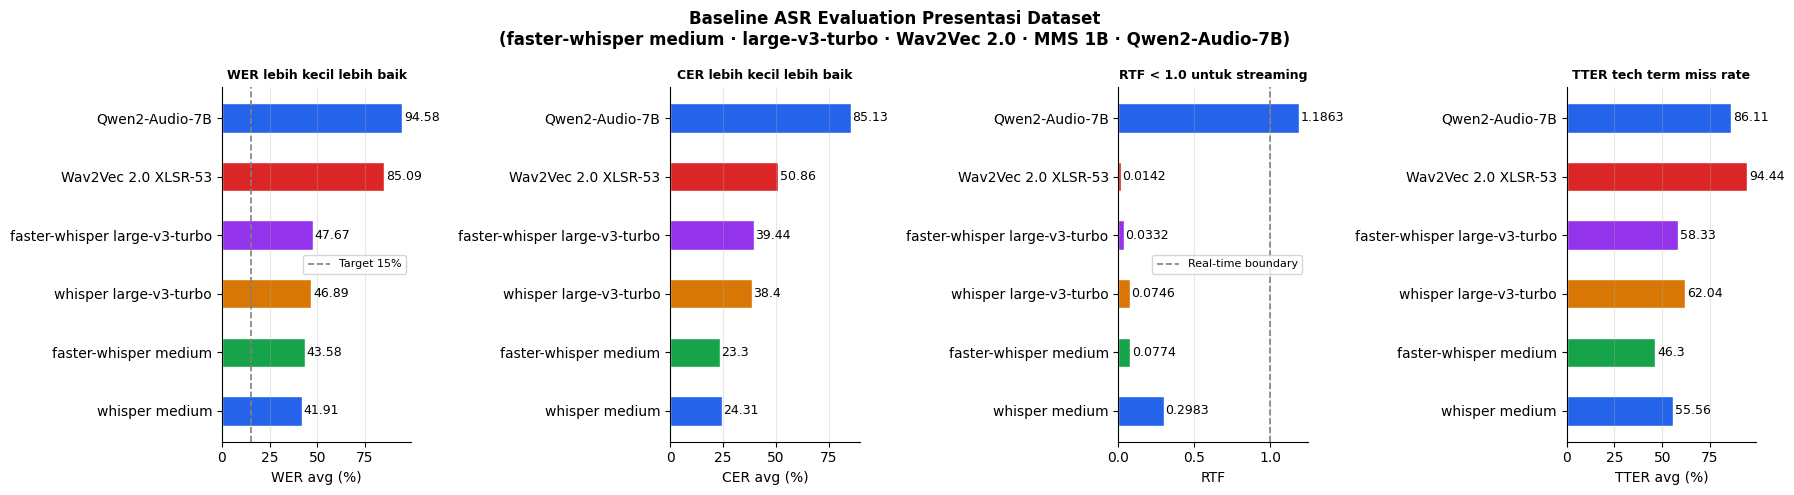

Plot disimpan: /kaggle/working/baseline_comparison.png


In [64]:
if rows:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle('Baseline ASR Evaluation Presentasi Dataset\n'
                 '(faster-whisper medium · large-v3-turbo · Wav2Vec 2.0 · MMS 1B · Qwen2-Audio-7B)',
                 fontsize=12, fontweight='bold')

    models = df['Model'].tolist()
    metrics = [
        (df['WER avg (%)'].tolist(),  'WER avg (%)',  'WER lebih kecil lebih baik',  15,  'Target 15%'),
        (df['CER avg (%)'].tolist(),  'CER avg (%)',  'CER lebih kecil lebih baik',  None, None),
        (df['RTF avg'].tolist(),      'RTF',          'RTF < 1.0 untuk streaming',   1.0, 'Real-time boundary'),
        (df['TTER avg (%)'].tolist(), 'TTER avg (%)', 'TTER tech term miss rate',    None, None),
    ]
    palette = ['#2563EB', '#16A34A', '#D97706', '#9333EA', '#DC2626'][:len(models)]

    for ax, (vals, xlabel, title, thresh, tlabel) in zip(axes, metrics):
        bars = ax.barh(models, vals, color=palette[:len(models)], edgecolor='white', height=0.5)
        if thresh:
            ax.axvline(thresh, color='gray', ls='--', lw=1.2, label=tlabel)
            ax.legend(fontsize=8)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_xlabel(xlabel)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_width() + max(vals)*0.01,
                    bar.get_y() + bar.get_height()/2,
                    f'{v}', va='center', fontsize=9)
        ax.grid(True, axis='x', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    out_fig = OUTPUT_DIR / 'baseline_comparison.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot disimpan: {out_fig}')


## 14. Simpan & Kesimpulan

In [65]:
results_save = {}
for k, v in results_all.items():
    results_save[k] = [{kk: vv for kk, vv in r.items() if kk != 'audio_array'} for r in v]

(OUTPUT_DIR / 'baseline_results.json').write_text(
    json.dumps(results_save, ensure_ascii=False, indent=2), encoding='utf-8')
print('Hasil disimpan ke /kaggle/working/baseline_results.json')

if rows:
    best_wer  = min(rows, key=lambda x: x['WER avg (%)'])
    best_rtf  = min(rows, key=lambda x: x['RTF avg'])
    best_tter = min(rows, key=lambda x: x['TTER avg (%)'])
    print()
    print('━' * 58)
    print('📋 KESIMPULAN BASELINE')
    print('━' * 58)
    print(f'✅ Akurasi terbaik  (WER↓)  : {best_wer["Model"]}  →  {best_wer["WER avg (%)"]:.2f}%')
    print(f'⚡ Kecepatan terbaik (RTF↓) : {best_rtf["Model"]}  →  RTF {best_rtf["RTF avg"]:.4f}')
    print(f'🔤 Tech term terbaik (TTER↓): {best_tter["Model"]}  →  {best_tter["TTER avg (%)"]:.2f}%')


Hasil disimpan ke /kaggle/working/baseline_results.json

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 KESIMPULAN BASELINE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Akurasi terbaik  (WER↓)  : whisper medium  →  41.91%
⚡ Kecepatan terbaik (RTF↓) : Wav2Vec 2.0 XLSR-53  →  RTF 0.0142
🔤 Tech term terbaik (TTER↓): faster-whisper medium  →  46.30%


In [66]:
!zip -r working2.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/working.zip (stored 0%)
  adding: kaggle/working/qwen2audio_presentasi1-audio.txt (deflated 36%)
  adding: kaggle/working/whisper_orig_turbo_presentasi3-audio.txt (deflated 62%)
  adding: kaggle/working/whisper_orig_presentasi1-audio.txt (deflated 56%)
  adding: kaggle/working/whisper_medium_presentasi1-audio.txt (deflated 54%)
  adding: kaggle/working/qwen2audio_presentasi2-audio.txt (deflated 38%)
  adding: kaggle/working/whisper_turbo_presentasi1-audio.txt (deflated 54%)
  adding: kaggle/working/whisper_medium_presentasi3-audio.txt (deflated 61%)
  adding: kaggle/working/presentasi1-audio_16k.wav (deflated 7%)
  adding: kaggle/working/qwen2audio_presentasi3-audio.txt (deflated 47%)
  adding: kaggle/working/presentasi2-audio_16k.wav (deflated 19%)
  adding: kaggle/working/whisper_orig_presentasi3-audio.txt (deflated 58%)
  adding: kaggle/working/presentasi3-audio_16k.wav (deflated 14%)
  adding: kaggle/working/whisper_tur